<a href="https://colab.research.google.com/github/benasphy/KNN/blob/main/KNN_From_Scratch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

In [38]:
class KNN:
  def __init__(self, k):
    self.k = k

  def fit(self, X, y):
    self.X_train = np.array(X)
    self.y_train = np.array(y)

  def _euclidean_distance(self, x1, x2):
    return np.sqrt(np.sum((x1-x2) ** 2))

  def predict(self, X):
    X = np.array(X)
    predictions = [self._predict_one(x) for x in X]
    return np.array(predictions)

  def _predict_one(self, x):
    #distance to all training points
    distances = [self._euclidean_distance(x, X_train) for X_train in self.X_train]
    #Get indices of nearest neighbors
    k_indices = np.argsort(distances)[:self.k]
    #Getting their labels
    k_nearest_labels = self.y_train[k_indices]
    #Majority vote
    most_common = Counter(k_nearest_labels).most_common(1)
    return most_common[0][0]

  def score(self, X, y):
    y_pred = self.predict(X)
    acc = np.mean(y_pred == y)
    return acc



In [39]:
data = {
    "Feature1": [1, 2, 3, 6, 7, 8],
    "Feature2": [1, 2, 3, 6, 7, 8],
    "Label":    [0, 0, 0, 1, 1, 1]
}

df = pd.DataFrame(data)
X = df[["Feature1", "Feature2"]].values
y = df["Label"].values

In [40]:
X_train, X_test = X[:4], X[4:]
y_train, y_test = y[:4], y[4:]

In [41]:
model = KNN(k=2)
model.fit(X_train, y_train)

In [42]:
predictions = model.predict(X_test)
predictions

array([1, 1])

In [43]:
acc = model.score(X_test, y_test)
acc

np.float64(1.0)

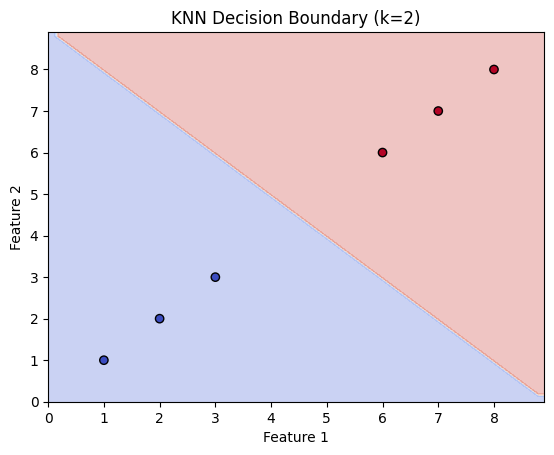

In [44]:
# Plot decision boundaries
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                     np.arange(y_min, y_max, 0.1))

# Predict for every point in grid
Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Draw background regions
plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')

# Plot data points
plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', cmap='coolwarm')
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title(f"KNN Decision Boundary (k={model.k})")
plt.show()
